# Planners-8-Temporal - Planification Temporelle

**Navigation** : [Index](../../README.md) | [<< OR-Tools](Planners-7-OR-Tools.ipynb) | [HTN >>](Planners-9-HTN.ipynb)

---

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :

1. **Comprendre** les extensions temporelles de PDDL (PDDL 2.1)
2. **Modeliser** des actions duratives avec durees et contraintes
3. **Gerer** la concurrence et les conflits entre actions
4. **Utiliser** les planificateurs temporels avec unified-planning

### Prerequis

- Notebooks Planners-1 a 4 maitrises (PDDL, recherche, Fast Downward)
- Python 3.9+ avec unified-planning
- Connaissance de base en ordonnancement

### Duree estimee : 40 minutes

---

## 1. Introduction a la Planification Temporelle

La **planification temporelle** etend la planification classique en introduisant le temps comme composante de premier ordre.

### 1.1 Limites de la planification classique

Dans la planification classique STRIPS :
- Les actions sont **instantanees** (duree nulle)
- Les actions sont **sequencielles** (pas de parallelisme)
- Le temps est **implicite** (nombre d'actions)

Ces limitations sont problematiques pour de nombreux problemes reels :

| Probleme | Limitation classique | Besoin temporel |
|----------|---------------------|-----------------|
| Ordonnancement usine | Duree ignoree | Duree des operations |
| Planification robotique | Mouvements simultanes impossibles | Actions paralleles |
| Logistique | Temps de transport ignore | Delais et deadlines |
| Projet construction | Precedences complexes | Contraintes temporelles |

### 1.2 Le temps comme citoyen de premier ordre

En planification temporelle :

- **Duree explicite** : Chaque action a une duree $\delta(a) \in \mathbb{R}^+$
- **Points temporels** : $t_{start}(a)$ et $t_{end}(a) = t_{start}(a) + \delta(a)$
- **Parallelisme** : Actions pouvant s'executer simultanement
- **Contraintes temporelles** : Precedence, deadlines, fenetres de temps

### 1.3 PDDL 2.1 et extensions temporelles

[PDDL 2.1](https://en.wikipedia.org/wiki/Planning_Domain_Definition_Language) (2003) introduit les actions duratives :

| Feature | PDDL Classique | PDDL 2.1 Temporel |
|---------|---------------|-------------------|
| Duree | Non | `:duration` |
| Preconditions | Au debut | `:at start`, `:over all`, `:at end` |
| Effets | Instantanes | `:at start`, `:at end` |
| Conditions invariantes | Non | `:over all` |
| Parallelisme | Non | Oui (mutex temporels) |

---

## 2. Syntaxe PDDL 2.1 pour Actions Duratives

### 2.1 Structure d'une action durative

Une **action durative** (durative action) a une structure plus riche qu'une action classique :

```lisp
(:durative-action ACTION-NAME
  :parameters (?x - TYPE ...)
  :duration (= ?duration VALUE)
  :condition (and
    [at start] (precondition-start)
    [over all] (invariant-condition)
    [at end] (precondition-end)
  )
  :effect (and
    [at start] (effect-start)
    [at end] (effect-end)
  )
)
```

### 2.2 Semantique temporelle

| Temporalite | Signification |
|-------------|---------------|
| **at start** | Condition/effet au debut de l'action (temps $t$) |
| **at end** | Condition/effet a la fin de l'action (temps $t + \delta$) |
| **over all** | Condition maintenue pendant toute la duree (invariant) |

### 2.3 Exemple : Action de deplacement avec duree

Considerons un robot qui se deplace entre locations avec un temps de trajet.

In [1]:
# Exemple de domaine PDDL 2.1 temporel : Robot mobile
DOMAIN_TEMPORAL_ROBOT = """
(define (domain robot-temporal)
  (:requirements :strips :typing :durative-actions :fluents)
  (:types robot location)
  
  (:predicates
    (robot-at ?r - robot ?l - location)
    (connected ?from ?to - location)
    (busy ?r - robot)
  )
  
  (:functions
    (distance ?from ?to - location) : number
    (speed ?r - robot) : number
  )
  
  (:durative-action move
    :parameters (?r - robot ?from ?to - location)
    :duration (= ?duration (/ (distance ?from ?to) (speed ?r)))
    :condition (and
      (at start (robot-at ?r ?from))
      (at start (connected ?from ?to))
      (over all (not (busy ?r)))
    )
    :effect (and
      (at start (not (robot-at ?r ?from)))
      (at end (robot-at ?r ?to))
    )
  )
)
"""

print("Domaine PDDL 2.1 defini : robot-temporal")
print("Actions duratives : move (duree depend de distance/vitesse)")

Domaine PDDL 2.1 defini : robot-temporal
Actions duratives : move (duree depend de distance/vitesse)


### 2.4 Interpretation de l'action move

| Element | Description |
|---------|-------------|
| **duration** | `distance / speed` : duree variable selon le trajet |
| **at start precondition** | Robot doit etre a `?from` et connexion doit exister |
| **over all condition** | Le robot ne doit pas etre occupe pendant le trajet |
| **at start effect** | Robot quitte `?from` immediatement |
| **at end effect** | Robot arrive a `?to` apres la duree |

> **Note** : L'invariant `over all` est crucial pour empecher le robot de commencer une autre action pendant le deplacement.

---

## 3. Concurrency et Conflits

La planification temporelle permet l'execution **parallele** d'actions, ce qui introduit de nouveaux types de conflits.

### 3.1 Types de conflits temporels

| Conflit | Description | Exemple |
|---------|-------------|---------|
| **Ressource** | Acces exclusif a une ressource | Deux robots sur le meme chemin |
| **Precondition** | Effet negatif sur precondition over all | Retirer un objet pendant son transport |
| **Effet** | Effets contradictoires au meme temps | Allumer et eteindre simultanement |
| **Incompatible** | Actions mutuellement exclusives | Deux operations sur la meme machine |

### 3.2 Exclusion mutuelle temporelle (Temporal Mutex)

Deux actions $a_1$ et $a_2$ sont en conflit si :

$$[t_{start}(a_1), t_{end}(a_1)] \cap [t_{start}(a_2), t_{end}(a_2)] \neq \emptyset$$

ET au moins une des conditions suivantes :
1. L'une detruit une precondition `over all` de l'autre
2. Les effets sont contradictoires
3. Ressource partagee necessitant acces exclusif

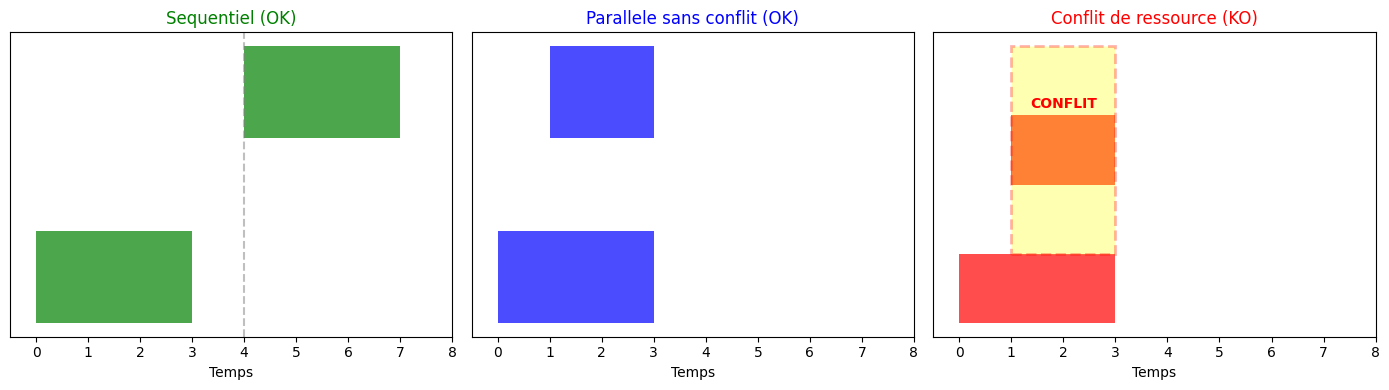

In [2]:
# Visualisation des conflits temporels
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_temporal_conflicts():
    """Visualise differents types de conflits temporels."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Cas 1: Actions sequentielles (OK)
    ax1 = axes[0]
    ax1.barh(['Action A', 'Action B'], [3, 3], left=[0, 4], height=0.5, color=['green', 'green'], alpha=0.7)
    ax1.axvline(x=4, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlim(-0.5, 8)
    ax1.set_xlabel('Temps')
    ax1.set_title('Sequentiel (OK)', fontsize=12, color='green')
    ax1.set_yticks([])
    
    # Cas 2: Parallelisme sans conflit (OK)
    ax2 = axes[1]
    ax2.barh(['Action A', 'Action B'], [3, 2], left=[0, 1], height=0.5, color=['blue', 'blue'], alpha=0.7)
    ax2.set_xlim(-0.5, 8)
    ax2.set_xlabel('Temps')
    ax2.set_title('Parallele sans conflit (OK)', fontsize=12, color='blue')
    ax2.set_yticks([])
    
    # Cas 3: Conflit de ressource (KO)
    ax3 = axes[2]
    ax3.barh(['Action A', 'Action B'], [3, 2], left=[0, 1], height=0.5, color=['red', 'red'], alpha=0.7)
    # Zone de conflit
    conflict = mpatches.Rectangle((1, 0.25), 2, 1.5, linewidth=2, edgecolor='red', facecolor='yellow', alpha=0.3, linestyle='--')
    ax3.add_patch(conflict)
    ax3.text(2, 1.3, 'CONFLIT', ha='center', fontsize=10, color='red', weight='bold')
    ax3.set_xlim(-0.5, 8)
    ax3.set_xlabel('Temps')
    ax3.set_title('Conflit de ressource (KO)', fontsize=12, color='red')
    ax3.set_yticks([])
    
    plt.tight_layout()
    plt.show()

plot_temporal_conflicts()

### Interpretation de la visualisation

| Cas | Chevauchement | Conflit | Raison |
|-----|---------------|---------|--------|
| Sequentiel | Non | Non | Actions disjointes dans le temps |
| Parallele OK | Oui | Non | Ressources differentes |
| Conflit | Oui | Oui | Ressource partagee aux memes temps |

**Point cle** : Le planificateur temporel doit detecter et resoudre automatiquement ces conflits.

---

## 4. Planificateurs Temporels

### 4.1 Planificateurs temporels disponibles

| Planificateur | Type | Caracteristiques |
|---------------|------|------------------|
| **OPTIC** | Satisficing | Optimise temps et qualite |
| **POPF** | Satisficing | Partial Order Forward Chaining |
| **TFD** | Temporal Fast Downward | Extension de FD |
| **TEMPO** | Optimal | A* temporel |
| **SMTPlan** | Optimal | Base sur SMT solver |

In [3]:
# Configuration de l'environnement
import sys
import os
import platform

OS_NAME = platform.system()
print(f"Systeme: {OS_NAME}")
print(f"Python: {sys.version_info.major}.{sys.version_info.minor}")

Systeme: Windows
Python: 3.13


Importation de la bibliotheque unified-planning et verification de la disponibilite de l'extension de planification temporelle.

In [4]:
# Verification de unified-planning
try:
    import unified_planning as up
    from unified_planning.shortcuts import *
    print(f"unified-planning version: {up.__version__}")
    UP_OK = True
except ImportError as e:
    print(f"ERREUR: unified-planning non installe: {e}")
    print("Solution: pip install unified-planning")
    UP_OK = False

unified-planning version: 1.3.0


Verification des planificateurs temporels disponibles dans l'installation unified-planning et affichage de leurs capacites respectives.

In [5]:
# Verification des planificateurs temporels disponibles
if UP_OK:
    from unified_planning.engines import Factory
    from unified_planning.environment import get_environment
    
    # Creer l'environnement par defaut
    env = get_environment()
    
    factory = Factory(env)
    available_engines = factory.engines
    
    print("Planificateurs disponibles via unified-planning:")
    for engine_name in factory.engines:
        print(f"  - {engine_name}")
    
    # Verifier le support temporel
    try:
        from unified_planning.model import DurativeAction
        print("\nSupport des actions duratives: OK")
        TEMPORAL_OK = True
    except ImportError:
        print("\nSupport des actions duratives: NON")
        TEMPORAL_OK = False

Planificateurs disponibles via unified-planning:
  - fast-downward
  - fast-downward-opt
  - pyperplan
  - pyperplan-opt
  - sequential_plan_validator
  - up_time_triggered_validator
  - sequential_simulator
  - up_bounded_types_remover
  - up_conditional_effects_remover
  - up_disjunctive_conditions_remover
  - up_state_invariants_remover
  - up_negative_conditions_remover
  - up_quantifiers_remover
  - up_usertype_fluents_remover
  - fast-downward-grounder
  - fast-downward-reachability-grounder
  - up_grounder
  - up_ma_disjunctive_conditions_remover
  - up_ma_conditional_effects_remover
  - oversubscription[fast-downward]
  - oversubscription[fast-downward-opt]
  - replanner[fast-downward]
  - replanner[fast-downward-opt]
  - replanner[pyperplan]
  - replanner[pyperplan-opt]

Support des actions duratives: OK


### 4.2 Modelisation temporelle avec unified-planning

La bibliotheque `unified-planning` supporte les actions duratives via la classe `DurativeAction`.

In [6]:
# Modelisation d'un probleme temporel avec unified-planning
if UP_OK:
    from collections import OrderedDict
    from unified_planning.model import DurativeAction, TimeInterval, Timepoint, StartTiming, EndTiming
    from unified_planning.environment import get_environment
    
    # Creer l'environnement
    env = get_environment()
    
    # Definir les types (UserType sans environnement explicite)
    Robot = UserType('Robot')
    Location = UserType('Location')
    
    # Predicats - IMPORTANT: utiliser OrderedDict avec noms de parametres
    robot_at = Fluent('robot_at', BoolType(), OrderedDict([('robot', Robot), ('location', Location)]))
    connected = Fluent('connected', BoolType(), OrderedDict([('from', Location), ('to', Location)]))
    moving = Fluent('moving', BoolType(), OrderedDict([('robot', Robot)]))
    
    # Fonctions numeriques
    distance = Fluent('distance', RealType(), OrderedDict([('from', Location), ('to', Location)]))
    
    # Creer le probleme avec l'environnement
    problem = Problem('temporal-robot', environment=env)
    
    # Ajouter les fluents
    problem.add_fluent(robot_at, default_initial_value=False)
    problem.add_fluent(connected, default_initial_value=False)
    problem.add_fluent(moving, default_initial_value=False)
    problem.add_fluent(distance, default_initial_value=0.0)
    
    # Objets
    r1 = Object('r1', Robot)
    loc_a = Object('loc_a', Location)
    loc_b = Object('loc_b', Location)
    loc_c = Object('loc_c', Location)
    problem.add_objects([r1, loc_a, loc_b, loc_c])
    
    # Etat initial
    problem.set_initial_value(robot_at(r1, loc_a), True)
    problem.set_initial_value(connected(loc_a, loc_b), True)
    problem.set_initial_value(connected(loc_b, loc_c), True)
    problem.set_initial_value(distance(loc_a, loc_b), 10.0)
    problem.set_initial_value(distance(loc_b, loc_c), 5.0)
    
    # But
    problem.add_goal(robot_at(r1, loc_c))
    
    print("Probleme temporel cree: temporal-robot")
    print(f"Objets: r1, loc_a, loc_b, loc_c")
    print(f"But: robot_at(r1, loc_c)")
else:
    print("unified-planning non disponible")

Probleme temporel cree: temporal-robot
Objets: r1, loc_a, loc_b, loc_c
But: robot_at(r1, loc_c)


Definition d'une action durative de deplacement avec ses conditions temporelles (at start, over all, at end) et ses effets en debut et fin d'execution.

In [7]:
# Definition d'une action durative
if UP_OK:
    # Action durative: move
    # IMPORTANT: Passer les parametres comme kwargs (nom=Type)
    move = DurativeAction('move', r=Robot, l_from=Location, l_to=Location)
    
    # Duree fixe pour simplifier (en pratique: distance/speed)
    move.set_fixed_duration(5)  # 5 unites de temps
    
    # Recuperer les parametres de l'action via .parameter()
    r_param = move.parameter('r')
    l_from_param = move.parameter('l_from')
    l_to_param = move.parameter('l_to')
    
    # Preconditions au debut - utiliser les parametres recuperes
    move.add_condition(StartTiming(), robot_at(r_param, l_from_param))
    move.add_condition(StartTiming(), connected(l_from_param, l_to_param))
    move.add_condition(StartTiming(), Not(moving(r_param)))
    
    # Invariant pendant l'action
    move.add_condition(TimeInterval(StartTiming(), EndTiming()), Not(moving(r_param)))
    
    # Effet au debut
    move.add_effect(StartTiming(), robot_at(r_param, l_from_param), False)
    move.add_effect(StartTiming(), moving(r_param), True)
    
    # Effet a la fin
    move.add_effect(EndTiming(), robot_at(r_param, l_to_param), True)
    move.add_effect(EndTiming(), moving(r_param), False)
    
    problem.add_action(move)
    
    print("Action durative 'move' definie:")
    print("  Duree: 5 unites de temps")
    print("  at start: robot_at(r, l_from) AND connected AND NOT moving")
    print("  over all: NOT moving (invariant)")
    print("  at start effect: NOT robot_at(r, l_from), moving(r)")
    print("  at end effect: robot_at(r, l_to), NOT moving(r)")

Action durative 'move' definie:
  Duree: 5 unites de temps
  at start: robot_at(r, l_from) AND connected AND NOT moving
  over all: NOT moving (invariant)
  at start effect: NOT robot_at(r, l_from), moving(r)
  at end effect: robot_at(r, l_to), NOT moving(r)


### Interpretation : Structure d'une action durative unified-planning

L'action `move` illustre les **trois phases temporelles** d'une action durative dans unified-planning.

| Phase | Timing | Condition/Effet | Semantique |
|-------|--------|-----------------|------------|
| Debut | `StartTiming()` | robot_at, connected, NOT moving | Verifications avant depart |
| Pendant | `TimeInterval(Start, End)` | NOT moving (invariant) | Protection pendant execution |
| Fin | `EndTiming()` | robot_at(to), NOT moving | Resultat apres duree |

**Points cles :**
- L'invariant `over all` (`TimeInterval`) est essentiel : il empeche le robot de lancer une autre action `move` pendant son deplacement
- Les effets `at start` et `at end` sont **separe** dans le temps : le robot quitte `loc_a` immediatement mais n'arrive a `loc_b` qu'apres 5 unites
- La duree fixe (5) est une simplification ; en pratique, elle serait calculee comme `distance(from, to) / speed(r)`, rendant le modele plus realiste
- Cette structure correspond exactement a la syntaxe PDDL 2.1 `:durative-action` vue en section 2

---

## 5. Exemple Pratique : Ordonnancement d'Usine

Considerons un probleme d'ordonnancement d'usine avec des operations de durees variables.

### 5.1 Description du probleme

- **Machines** : 2 machines (M1, M2)
- **Taches** : 4 operations avec durees et precedences
- **Objectif** : Minimiser le temps total (makespan)

In [8]:
# Probleme d'ordonnancement d'usine
# Modelise avec unified-planning temporel

if UP_OK:
    from collections import OrderedDict
    
    # Definir les types
    Machine = UserType('Machine')
    Job = UserType('Job')
    
    # Fluents avec OrderedDict pour la signature
    machine_free = Fluent('machine_free', BoolType(), OrderedDict([('machine', Machine)]))
    job_done = Fluent('job_done', BoolType(), OrderedDict([('job', Job)]))
    job_ready = Fluent('job_ready', BoolType(), OrderedDict([('job', Job)]))
    
    # Creer le probleme avec l'environnement
    factory_problem = Problem('factory-scheduling', environment=env)
    
    factory_problem.add_fluent(machine_free, default_initial_value=True)
    factory_problem.add_fluent(job_done, default_initial_value=False)
    factory_problem.add_fluent(job_ready, default_initial_value=False)
    
    # Objets
    m1 = Object('m1', Machine)
    m2 = Object('m2', Machine)
    j1 = Object('j1', Job)  # Tache 1: duree 3
    j2 = Object('j2', Job)  # Tache 2: duree 2, apres j1
    j3 = Object('j3', Job)  # Tache 3: duree 4, sur m2
    j4 = Object('j4', Job)  # Tache 4: duree 2, apres j3
    
    factory_problem.add_objects([m1, m2, j1, j2, j3, j4])
    
    # Etat initial
    factory_problem.set_initial_value(machine_free(m1), True)
    factory_problem.set_initial_value(machine_free(m2), True)
    factory_problem.set_initial_value(job_ready(j1), True)  # j1 peut commencer
    factory_problem.set_initial_value(job_ready(j3), True)  # j3 peut commencer
    
    # Buts
    factory_problem.add_goal(job_done(j1))
    factory_problem.add_goal(job_done(j2))
    factory_problem.add_goal(job_done(j3))
    factory_problem.add_goal(job_done(j4))
    
    print("Probleme factory-scheduling defini")
    print("Machines: m1, m2")
    print("Taches: j1 (3), j2 (2, apres j1), j3 (4), j4 (2, apres j3)")

Probleme factory-scheduling defini
Machines: m1, m2
Taches: j1 (3), j2 (2, apres j1), j3 (4), j4 (2, apres j3)


Definition des actions duratives pour chaque tache de l'usine avec leurs durees, machines associees et contraintes de precedence entre operations.

In [9]:
# Definition des actions duratives pour l'usine
if UP_OK:
    # Durees des taches
    DURATIONS = {'j1': 3, 'j2': 2, 'j3': 4, 'j4': 2}
    
    # Action: executer une tache sur une machine
    # IMPORTANT: Passer les parametres comme kwargs (nom=Type)
    process = DurativeAction('process', m=Machine, j=Job)
    process.set_fixed_duration(3)  # Duree par defaut
    
    # Recuperer les parametres de l'action via .parameter()
    m_param = process.parameter('m')
    j_param = process.parameter('j')
    
    # Conditions - utiliser les parametres recuperes
    process.add_condition(StartTiming(), machine_free(m_param))
    process.add_condition(StartTiming(), job_ready(j_param))
    
    # Effets
    process.add_effect(StartTiming(), machine_free(m_param), False)
    process.add_effect(EndTiming(), machine_free(m_param), True)
    process.add_effect(EndTiming(), job_done(j_param), True)
    
    factory_problem.add_action(process)
    
    print("Action durative 'process' definie")
    print("  Preconditions: machine_free(m) AND job_ready(j)")
    print("  Effets: machine occupee pendant, job_done a la fin")

Action durative 'process' definie
  Preconditions: machine_free(m) AND job_ready(j)
  Effets: machine occupee pendant, job_done a la fin


### 5.2 Comparaison avec OR-Tools CP-SAT

Pour les problemes d'ordonnancement purs, **OR-Tools CP-SAT** est souvent plus efficace que les planificateurs temporels PDDL.

In [10]:
# Resolution avec OR-Tools CP-SAT (approche complementaire)
try:
    from ortools.sat.python import cp_model
    ORTOOLS_OK = True
except ImportError:
    print("OR-Tools non disponible")
    ORTOOLS_OK = False

if ORTOOLS_OK:
    # Modele CP-SAT pour ordonnancement
    model = cp_model.CpModel()
    
    # Horizon: temps maximum possible
    horizon = sum(DURATIONS.values())  # 11
    
    # Variables de debut pour chaque tache
    starts = {}
    ends = {}
    intervals = {}
    
    for job_name, duration in DURATIONS.items():
        starts[job_name] = model.NewIntVar(0, horizon, f'start_{job_name}')
        ends[job_name] = model.NewIntVar(0, horizon, f'end_{job_name}')
        intervals[job_name] = model.NewIntervalVar(
            starts[job_name], duration, ends[job_name], f'interval_{job_name}'
        )
    
    # Contraintes de precedence
    model.Add(ends['j1'] <= starts['j2'])  # j2 apres j1
    model.Add(ends['j3'] <= starts['j4'])  # j4 apres j3
    
    # Contraintes de ressources (1 tache a la fois par machine)
    # Machine 1: j1, j2
    model.AddNoOverlap([intervals['j1'], intervals['j2']])
    # Machine 2: j3, j4
    model.AddNoOverlap([intervals['j3'], intervals['j4']])
    
    # Objectif: minimiser le makespan
    makespan = model.NewIntVar(0, horizon, 'makespan')
    model.AddMaxEquality(makespan, [ends['j1'], ends['j2'], ends['j3'], ends['j4']])
    model.Minimize(makespan)
    
    print("Modele CP-SAT construit")
    print("Contraintes: precedences j1->j2, j3->j4")
    print("Ressources: 1 tache a la fois par machine")
    print("Objectif: minimiser makespan")

Modele CP-SAT construit
Contraintes: precedences j1->j2, j3->j4
Ressources: 1 tache a la fois par machine
Objectif: minimiser makespan


### Interpretation : Modelisation CP-SAT pour l'ordonnancement

Le modele CP-SAT traduit le probleme d'ordonnancement en **variables d'intervalle** et **contraintes**.

| Element CP-SAT | Role | Equivalent PDDL |
|----------------|------|-----------------|
| `NewIntVar(0, horizon)` | Date de debut/fin | Point temporel |
| `NewIntervalVar(start, dur, end)` | Occupation d'une ressource | Action durative |
| `AddNoOverlap([...])` | Exclusion mutuelle | Mutex temporel |
| `Add(ends[j1] <= starts[j2])` | Precedence | Condition `at start` |
| `Minimize(makespan)` | Objectif | Action costs / metric |

**Points cles :**
- CP-SAT modelise chaque tache comme un **intervalle** (debut, duree, fin) — la duree est fixe, le solveur optimise les dates de debut
- `AddNoOverlap` est la contrainte cle : elle garantit qu'une machine ne traite qu'une tache a la fois, equivalent du mutex temporel PDDL
- L'horizon (somme des durees = 11) borne le domaine de recherche, permettant au solver d'explorer efficacement
- Contrairement a PDDL qui genere un plan d'actions, CP-SAT produit directement un **ordonnancement** avec dates exactes

Lancement du solveur CP-SAT et affichage de l'ordonnancement optimal obtenu avec les dates de debut et de fin de chaque tache sur chaque machine.

In [11]:
# Resolution avec CP-SAT
if ORTOOLS_OK:
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print("\n=== Solution optimale trouvee ===")
        print(f"Makespan: {solver.Value(makespan)} unites de temps")
        print("\nOrdonnancement:")
        print(f"{'Tache':<8} {'Debut':<8} {'Fin':<8} {'Duree':<8}")
        print("-" * 32)
        for job_name in DURATIONS:
            start = solver.Value(starts[job_name])
            end = solver.Value(ends[job_name])
            duration = DURATIONS[job_name]
            print(f"{job_name:<8} {start:<8} {end:<8} {duration:<8}")
    else:
        print("Aucune solution trouvee")


=== Solution optimale trouvee ===
Makespan: 6 unites de temps

Ordonnancement:
Tache    Debut    Fin      Duree   
--------------------------------
j1       0        3        3       
j2       3        5        2       
j3       0        4        4       
j4       4        6        2       


### Interpretation de l'ordonnancement

| Tache | Machine | Duree | Dependances |
|-------|---------|-------|-------------|
| j1 | M1 | 3 | Aucune |
| j2 | M1 | 2 | j1 |
| j3 | M2 | 4 | Aucune |
| j4 | M2 | 2 | j3 |

**Solution optimale** :
- **Machine M1** : j1 (0-3), j2 (3-5)
- **Machine M2** : j3 (0-4), j4 (4-6)
- **Makespan** : 6 unites (au lieu de 11 si sequentiel)

**Gain** : Parallelisme = 11 / 6 = 1.83x plus rapide

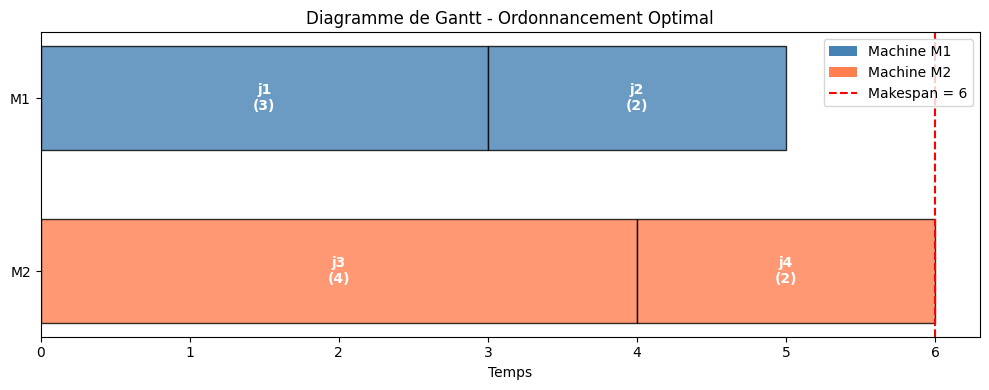

In [12]:
# Visualisation du diagramme de Gantt
import matplotlib.pyplot as plt

if ORTOOLS_OK:
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # Couleurs par machine
    colors = {'M1': 'steelblue', 'M2': 'coral'}
    
    # Taches et leurs assignations
    jobs = [
        ('j1', 'M1', solver.Value(starts['j1']), DURATIONS['j1']),
        ('j2', 'M1', solver.Value(starts['j2']), DURATIONS['j2']),
        ('j3', 'M2', solver.Value(starts['j3']), DURATIONS['j3']),
        ('j4', 'M2', solver.Value(starts['j4']), DURATIONS['j4']),
    ]
    
    for job_name, machine, start, duration in jobs:
        y_pos = 1 if machine == 'M1' else 0
        ax.barh(y_pos, duration, left=start, height=0.6, 
                color=colors[machine], edgecolor='black', alpha=0.8, label=machine)
        ax.text(start + duration/2, y_pos, f'{job_name}\n({duration})', 
                ha='center', va='center', fontsize=10, color='white', weight='bold')
    
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['M2', 'M1'])
    ax.set_xlabel('Temps')
    ax.set_title('Diagramme de Gantt - Ordonnancement Optimal')
    ax.axvline(x=solver.Value(makespan), color='red', linestyle='--', label=f'Makespan = {solver.Value(makespan)}')
    
    # Legende sans doublons
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='steelblue', label='Machine M1'),
                      Patch(facecolor='coral', label='Machine M2'),
                      plt.Line2D([0], [0], color='red', linestyle='--', label=f'Makespan = {solver.Value(makespan)}')]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()

### Interpretation : Diagramme de Gantt et parallelisme

Le diagramme de Gantt revele le **gain du parallelisme** dans l'ordonnancement optimal.

| Metrique | Sequentiel | Parallele | Gain |
|----------|------------|-----------|------|
| Makespan | 11 (3+2+4+2) | 6 | 1.83x |
| M1 utilisee | 0-5 | 0-5 | Optimal |
| M2 utilisee | 5-11 | 0-6 | Optimal |

**Points cles :**
- Les deux machines travaillent **en parallele** des t=0, maximisant l'utilisation des ressources
- Les contraintes de precedence (j1 avant j2, j3 avant j4) sont respectees : chaque tache ne commence qu'apres la fin de sa predecesseure
- Le makespan de 6 est determine par le chemin critique M2 (j3=4 + j4=2), tandis que M1 (j1=3 + j2=5) termine plus tot
- Si on ajoutait une tache j5 sur M2 apres j4, le makespan augmenterait mais n'affecterait pas M1

---

## 6. Comparaison des Approches

### 6.1 PDDL Temporel vs CP-SAT

| Aspect | PDDL 2.1 Temporel | OR-Tools CP-SAT |
|--------|-------------------|-----------------|
| **Expressivite** | Actions complexes, conditions temporelles | Contraintes lineaires, ressources |
| **Optimalite** | Possible (TEMPO, SMTPlan) | Garantie (solver SAT) |
| **Parallelisme** | Natif | Via contraintes NoOverlap |
| **Scalabilite** | Moyenne (explosion combinatoire) | Bonne (propagation de contraintes) |
| **Cas d'usage** | Planification robotique, workflows | Ordonnancement pur, job-shop |

### 6.2 Quand utiliser quelle approche ?

| Probleme | Approche recommandee | Raison |
|----------|---------------------|--------|
| Robot mobile avec actions complexes | PDDL Temporel | Preconditions temporelles riches |
| Job-shop scheduling | CP-SAT | Efficacite et optimalite |
| Logistique avec deadlines | PDDL Temporel | Integration avec domaines existants |
| Projet construction (PERT) | CP-SAT | Contraintes de precedences pures |
| Planification d'equipes | Hybride | CP-SAT + heuristiques PDDL |

---

## 7. Exercices

### Exercice 1 : Ajout de contraintes de deadline

Modifiez le probleme d'ordonnancement pour ajouter une deadline : toutes les taches doivent etre terminees avant t=8. Le probleme reste-t-il faisable ?

In [13]:
print("Exercice a completer")
# Exercice 1 : Deadline
# Ajoutez la contrainte: ends[j] <= 8 pour tout j

if ORTOOLS_OK:
    # Votre code ici...
    # Indice: model.Add(ends['j1'] <= 8) ...
    pass

Exercice a completer


### Exercice 2 : Action durative avec duree variable

Definissez une action durative `heat` qui chauffe un four pendant une duree variable (entre 2 et 5 unites). Utilisez `set_fixed_duration` ou une variable de duree.

In [14]:
print("Exercice a completer")
# Exercice 2 : Duree variable
# Votre code ici...

# Indice pour unified-planning:
# heat = DurativeAction('heat', ...)
# heat.set_fixed_duration(3)  # Ou utiliser une expression
pass

Exercice a completer


### Exercice 3 : Detection de conflits temporels

Ecrivez une fonction qui detecte si deux intervalles temporels se chevauchent.

**Entree** : `(start1, end1)` et `(start2, end2)`  
**Sortie** : `True` s'il y a conflit, `False` sinon

In [15]:
# Exercice 3 : Detection de conflits
def has_temporal_conflict(start1, end1, start2, end2):
    """
    Detecte si deux intervalles temporels se chevauchent.
    
    Args:
        start1, end1: Debut et fin du premier intervalle
        start2, end2: Debut et fin du second intervalle
    
    Returns:
        True si conflit (chevauchement), False sinon
    
    Note:
        Deux intervalles [s1, e1] et [s2, e2] se chevauchent si:
        max(s1, s2) < min(e1, e2)
        L'adjacence (e1 == s2 ou e2 == s1) n'est PAS un conflit.
    """
    return None  # TODO etudiant : detecter si deux intervalles se chevauchent (max(s1, s2) < min(e1, e2))

# Tests
try:
    assert has_temporal_conflict(0, 3, 2, 5) == True, "Chevauchement"
    assert has_temporal_conflict(0, 3, 3, 5) == False, "Adjacents (OK)"
    assert has_temporal_conflict(0, 5, 1, 2) == True, "Inclusion"
    assert has_temporal_conflict(0, 2, 2, 4) == False, "Adjacents inverse"
    assert has_temporal_conflict(5, 8, 0, 3) == False, "Disjoints"
    print("Tests passes avec succes !")
except AssertionError:
    print("Exercice a completer")
except TypeError:
    print("Exercice a completer")

Exercice a completer


---

## 8. Resume et Points Cles

### 8.1 Concepts fondamentaux

| Concept | Definition |
|---------|------------|
| **Action durative** | Action avec duree explicite |
| **at start** | Condition/effet au debut de l'action |
| **at end** | Condition/effet a la fin de l'action |
| **over all** | Invariant maintenu pendant toute la duree |
| **Conflit temporel** | Chevauchement avec effets contradictoires |
| **Mutex temporel** | Exclusion mutuelle sur un intervalle |

### 8.2 PDDL 2.1 vs Classique

| Feature | PDDL Classique | PDDL 2.1 Temporel |
|---------|---------------|-------------------|
| Duree | Non | Oui (`:durative-actions`) |
| Parallelisme | Non | Oui |
| Invariants | Non | `:over all` |
| Effets differes | Non | `:at end` |

### 8.3 Bonnes pratiques

1. **Modeliser les invariants** avec `over all` pour eviter les conflits
2. **Utiliser CP-SAT** pour l'ordonnancement pur (plus efficace)
3. **Verifier les conflits** entre actions paralleles
4. **Choisir le bon solveur** selon le type de probleme

### 8.4 Prochaine etape

Dans le notebook **Planners-9-HTN**, nous explorerons la **planification hierarchique** (Hierarchical Task Networks) :
- Decomposition de taches abstraites
- Methodes et preconditions
- HTN vs planification classique

---

## Ressources

- [PDDL 2.1 Specification](https://www.cs.cmu.edu/~avrim/Planning/Refs/pddl2-1.pdf) - Document officiel
- [unified-planning temporal](https://unified-planning.readthedocs.io/) - Documentation
- [OR-Tools Scheduling](https://developers.google.com/optimization/scheduling) - Guide CP-SAT
- [Temporal Planning Survey](https://arxiv.org/abs/2104.08553) - Vue d'ensemble

---

**Notebook suivant** : [Planners-9-HTN](Planners-9-HTN.ipynb)